# Week 4: Machine Learning Model Development and Evaluation

## E-Commerce Revenue Prediction Using Machine Learning

This project develops and evaluates a machine learning regression model for predicting e-commerce order revenue.

### Model
Random Forest Regressor

### Target Variable
Revenue

### Technologies
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# Load Dataset

In [2]:
file_path = "../Week-2-Advanced-Data-Visualization/ecommerce_sales_analytics_5000.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (5000, 12)


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


# Dataset Inspection

In [3]:
print("========== DATASET INFORMATION ==========")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

========== DATASET INFORMATION ==========

Columns:
['order_id', 'order_date', 'customer_id', 'product_category', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'revenue']

Data Types:
order_id              int64
order_date              str
customer_id           int64
product_category        str
region                  str
quantity              int64
unit_price          float64
discount            float64
payment_method          str
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object

Missing Values:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Duplicate Rows:
0


# Data Cleaning

In [4]:
# Convert date
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

# Remove rows with missing target
df = df.dropna(subset=["revenue"])

# Remove duplicate rows
df = df.drop_duplicates()

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (5000, 12)


# Feature Engineering

In [5]:
df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["order_dayofweek"] = df["order_date"].dt.dayofweek

display(df.head())

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,order_year,order_month,order_day,order_dayofweek
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,1,5
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,2,6
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022,1,3,0
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,4,1
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,5,2


# Select Features

In [6]:
features = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "product_category",
    "region",
    "payment_method",
    "order_year",
    "order_month",
    "order_day",
    "order_dayofweek"
]

target = "revenue"

X = df[features]
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

Features:
['quantity', 'unit_price', 'discount', 'delivery_days', 'customer_rating', 'product_category', 'region', 'payment_method', 'order_year', 'order_month', 'order_day', 'order_dayofweek']

Target:
revenue

X Shape: (5000, 12)
y Shape: (5000,)


# Identify Numeric and Categorical Features


In [7]:
numeric_features = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "order_year",
    "order_month",
    "order_day",
    "order_dayofweek"
]

categorical_features = [
    "product_category",
    "region",
    "payment_method"
]

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['quantity', 'unit_price', 'discount', 'delivery_days', 'customer_rating', 'order_year', 'order_month', 'order_day', 'order_dayofweek']

Categorical Features:
['product_category', 'region', 'payment_method']


# Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 4000
Testing Samples: 1000


# Preprocessing

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


# Baseline Model

In [10]:
baseline_model = DummyRegressor(
    strategy="mean"
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("========== BASELINE MODEL ==========")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²:", baseline_r2)

========== BASELINE MODEL ==========
MAE: 657.265636465
RMSE: 821.6145196249869
R²: -0.0019082908462055848


# Random Forest Model

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", rf_model)
    ]
)

print("Random Forest pipeline created!")

Random Forest pipeline created!


# Train Model

In [12]:
print("Training Random Forest model...")

model.fit(
    X_train,
    y_train
)

print("Model training completed!")

Training Random Forest model...
Model training completed!


# Predictions

In [13]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 Predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 Predictions:
[2124.63095 2355.5198  2709.48015 1746.99305 2645.93575  285.7537
  836.99545 2581.3985   309.3762   573.30615]


# Model Evaluation

In [14]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("========== RANDOM FOREST RESULTS ==========")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

========== RANDOM FOREST RESULTS ==========
MAE  : 21.33
MSE  : 1002.55
RMSE : 31.66
R²   : 0.9985


# Model Comparison

In [15]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        mae
    ],
    "RMSE": [
        baseline_rmse,
        rmse
    ],
    "R2": [
        baseline_r2,
        r2
    ]
})

display(comparison)

,Model,MAE,RMSE,R2
0,Baseline,657.265636,821.61452,-0.001908
1,Random Forest,21.333535,31.66311,0.998512



## Visualization 1: Actual vs Predicted Revenue

This scatter plot compares the actual revenue values with the values predicted by the Random Forest model. Points closer to the diagonal relationship indicate more accurate predictions. The visualization helps evaluate how closely the model follows the actual revenue values.

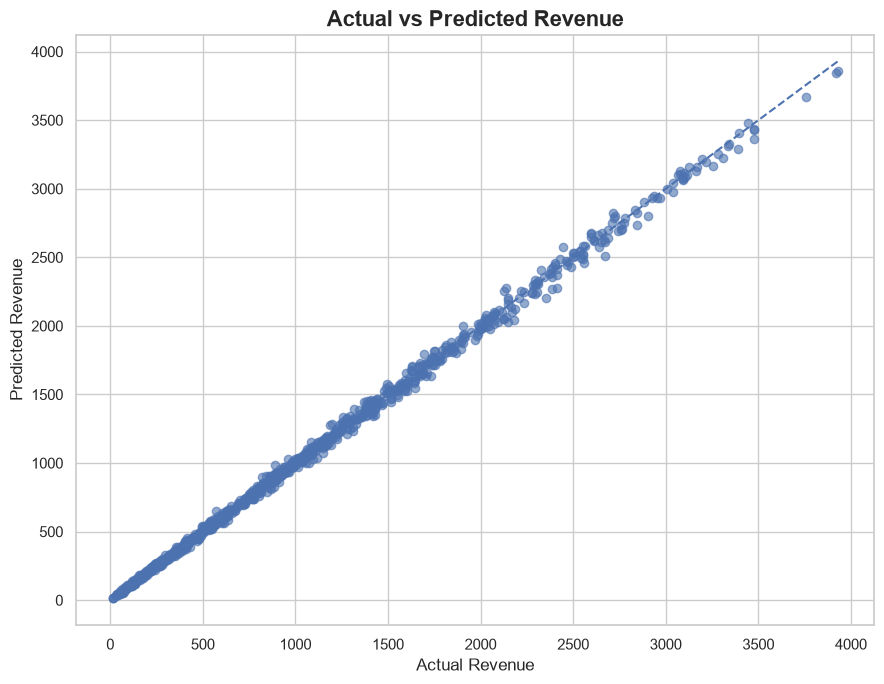

In [16]:
plt.figure(figsize=(9, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(
    "Actual vs Predicted Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.tight_layout()
plt.show()

# VISUALIZATION 2 — Residual Distribution
VISUALIZATION 2 — Residual Distribution

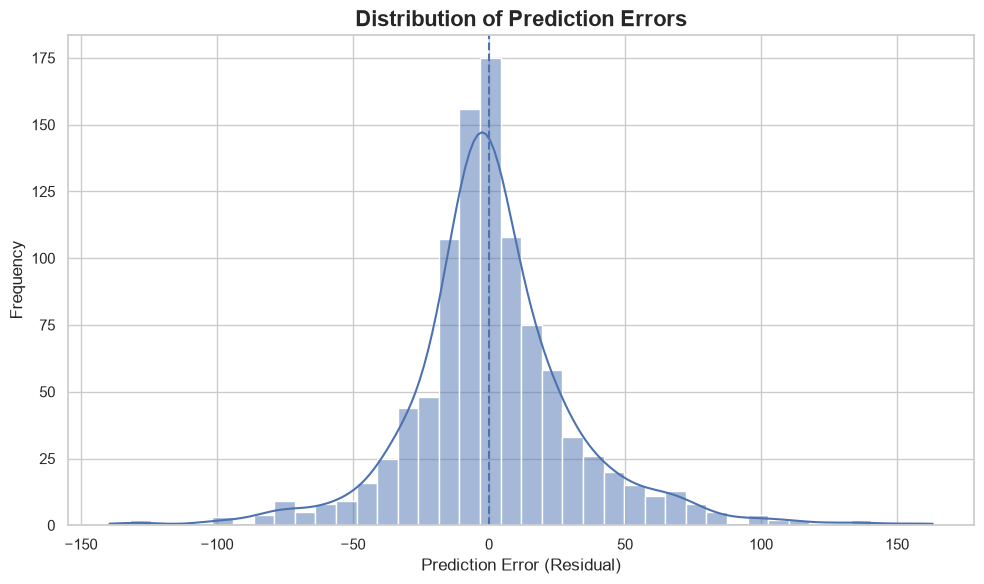

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Distribution of Prediction Errors",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Prediction Error (Residual)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# VISUALIZATION 3 — Residuals vs Predictions

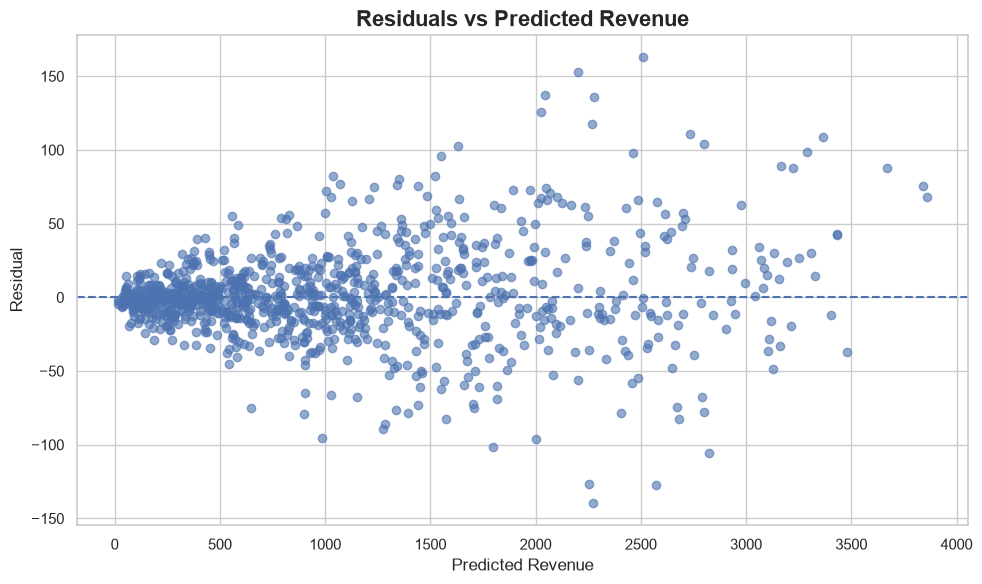

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Residuals vs Predicted Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Revenue")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

# VISUALIZATION 4 — Model Performance

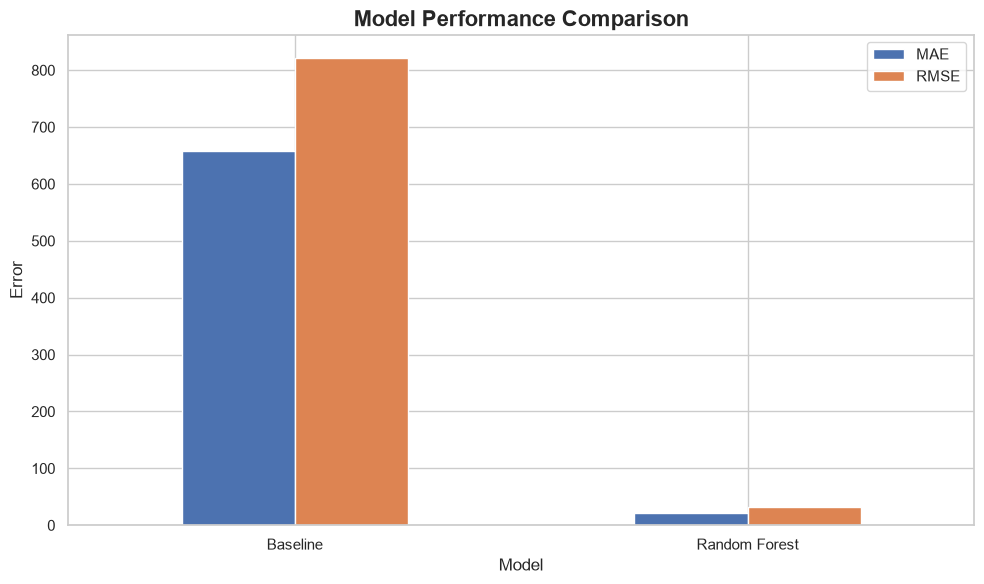

In [19]:
comparison_plot = comparison.set_index(
    "Model"
)

comparison_plot[
    ["MAE", "RMSE"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Error")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Feature Importance

In [20]:
# Get transformed feature names
preprocessor_fitted = model.named_steps[
    "preprocessor"
]

encoded_names = (
    preprocessor_fitted
    .named_transformers_["categorical"]
    .get_feature_names_out(
        categorical_features
    )
)

feature_names = np.concatenate([
    encoded_names,
    numeric_features
])

importances = (
    model.named_steps["regressor"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    feature_importance.head(15)
)

,Feature,Importance
12,unit_price,0.484913
11,quantity,0.477905
13,discount,0.035337
15,customer_rating,0.000285
18,order_day,0.000276
16,order_year,0.000237
14,delivery_days,0.000211
17,order_month,0.000198
19,order_dayofweek,0.000174
9,payment_method_Card,0.000049


# VISUALIZATION 5 — Feature Importance

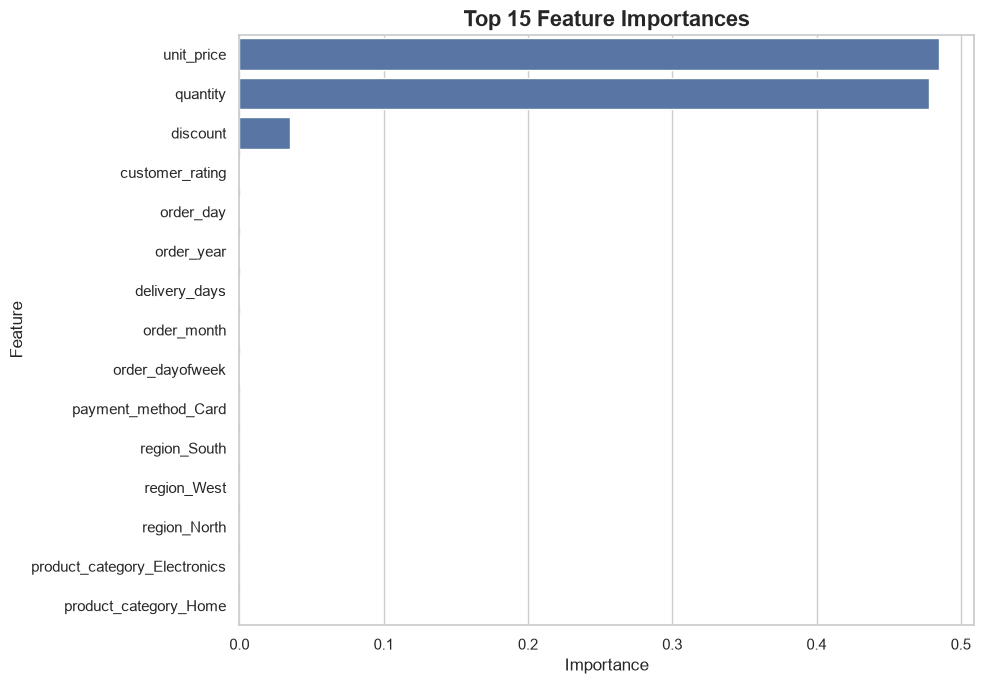

In [21]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Feature Importances",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Cross Validation

In [23]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("5-Fold Cross Validation R² Scores:")
print(cv_scores)

print(
    "\nMean Cross-Validation R²:",
    cv_scores.mean()
)

print(
    "Standard Deviation:",
    cv_scores.std()
)

5-Fold Cross Validation R² Scores:
[0.99852526 0.99847846 0.99834225 0.99841016 0.99850636]

Mean Cross-Validation R²: 0.9984524963391721
Standard Deviation: 6.755322915834978e-05


# Error Analysis

In [24]:
error_analysis = pd.DataFrame({
    "Actual Revenue": y_test.values,
    "Predicted Revenue": y_pred,
    "Absolute Error": np.abs(
        y_test.values - y_pred
    ),
    "Residual": (
        y_test.values - y_pred
    )
})

display(
    error_analysis
    .sort_values(
        "Absolute Error",
        ascending=False
    )
    .head(10)
)

,Actual Revenue,Predicted Revenue,Absolute Error,Residual
723,2673.59,2510.43150,163.15850,163.15850
668,2354.03,2201.22635,152.80365,152.80365
651,2135.11,2274.60980,139.49980,-139.49980
578,2181.69,2044.36360,137.32640,137.32640
788,2411.91,2275.72095,136.18905,136.18905
312,2444.26,2571.65725,127.39725,-127.39725
76,2127.63,2254.16015,126.53015,-126.53015
400,2150.64,2025.18805,125.45195,125.45195
196,2383.20,2265.69875,117.50125,117.50125
288,2846.35,2735.61965,110.73035,110.73035


# Final Summary

In [25]:
print("=" * 55)
print("FINAL MACHINE LEARNING MODEL SUMMARY")
print("=" * 55)

print(f"\nTraining Samples: {len(X_train)}")
print(f"Testing Samples : {len(X_test)}")

print("\nRandom Forest Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

print("\nBaseline Performance:")
print(f"MAE  : {baseline_mae:.2f}")
print(f"RMSE : {baseline_rmse:.2f}")
print(f"R²   : {baseline_r2:.4f}")

print("\nCross-Validation:")
print(f"Mean R² : {cv_scores.mean():.4f}")
print(f"Std R²  : {cv_scores.std():.4f}")

FINAL MACHINE LEARNING MODEL SUMMARY

Training Samples: 4000
Testing Samples : 1000

Random Forest Performance:
MAE  : 21.33
RMSE : 31.66
R²   : 0.9985

Baseline Performance:
MAE  : 657.27
RMSE : 821.61
R²   : -0.0019

Cross-Validation:
Mean R² : 0.9985
Std R²  : 0.0001


## Key Findings

The Random Forest regression model was developed to predict e-commerce order revenue using transaction, pricing, discount, delivery, customer rating, product category, region, payment method, and date-related features.

The model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. A simple baseline model was also created to provide a reference point for evaluating whether the machine learning model provides meaningful improvement.

The Actual vs Predicted visualization was used to assess prediction accuracy, while residual plots were used to identify systematic prediction errors. Feature importance analysis was used to identify the variables that contributed most strongly to the Random Forest predictions.

The final conclusions should be based on the actual metrics produced after executing the notebook. Particular attention should be given to the comparison between the Random Forest and baseline model, cross-validation stability, and the distribution of residual errors.

## Model Limitations

1. The dataset contains 5,000 transactions and may not represent all e-commerce businesses.

2. The model predicts revenue, but revenue is not the same as profit.

3. The dataset does not contain potentially important variables such as marketing expenditure, product cost, customer acquisition cost, or competitor pricing.

4. Random Forest models can be computationally more expensive than simple linear models.

5. Feature importance indicates predictive usefulness within the model but should not be interpreted as proof of causation.

6. The model may perform differently on future data if customer behaviour, pricing, or market conditions change.

7. Further hyperparameter tuning and additional data could potentially improve performance.

## Conclusion

This Week 4 project demonstrated a complete machine learning workflow for e-commerce revenue prediction using Python. The process included data loading, cleaning, feature engineering, categorical encoding, train-test splitting, model training, prediction, evaluation, visualization, and error analysis.

A Random Forest Regressor was selected because revenue is a continuous numerical target and the dataset contains a combination of numerical and categorical variables. A baseline model was also developed to provide a meaningful benchmark for evaluating the machine learning model.

The model was evaluated using MAE, RMSE, and R² metrics. Actual versus predicted values and residual visualizations were used to understand prediction quality and possible sources of error. Feature importance analysis provided additional insight into the variables used by the model.

Future improvements could include hyperparameter optimization, additional feature engineering, alternative regression algorithms, larger datasets, and systematic monitoring of model performance on new data.

Overall, the project demonstrates the practical application of machine learning for predictive data analysis and provides a foundation for more advanced modeling and strategic recommendations.